# Resistance mutations in aquatic plastisphere microbiomes

All script files are located in `sbatch_files/`. 

Steps before this notebook:
1. Download the fastq data (specified in *download.txt*) using `download.sh` 
2. Run Pipeline 1, see TODO_URL_TO_IT for more details. TODO: Ok to link to it or just describe it?
3. Download the card database using `download_card.sh`
4. Build the database for MuMaMe using `mumame_build.sh`
5. Run MuMaMe using `split_mumame.sh`, it will be grouped according to *beginning_filenames.txt*, in order to speed up the operation.
6. The files *\*.table.txt* and *\*.per-mutation.txt* will be used below.

# Data analysis
## Import data

In [1]:
rm(list = ls())
# Load Libraries
library("tidyverse")
library("ggthemes")
library("ggsignif")
library("scales")
library("microeco")
library("ALDEx2")
library("randomForest")

# List all relevant files
TABLE = TRUE
if (TABLE) {
   all_files_list <- list.files(path = "Mumame_results", pattern = "*.table.txt", full.names = TRUE) 
} else {
   all_files_list <- list.files(path = "Mumame_results", pattern = "*.per-mutation.txt", full.names = TRUE)
}
# See also pattern = "*.table.txt"
# per-mutation splits the Accession into one line per mutation, and uses the same hits for all. Easier with splitting below but result feels it could be wrong?

# Create the beginnings of the large dataframe
df_counts <- read_tsv(all_files_list[1], show_col_types = FALSE)

# Loop over all files, joining it to the larger dataframe. 
for (file in all_files_list[-1]) {
  df_counts <- read_tsv(file = file, show_col_types = FALSE) %>%
    full_join(df_counts, ., by = "Accession")
}

# Rename to not confuse with ARO accession later
df_counts <- df_counts %>%
  rename(Description = Accession)

if (TABLE) {
  # Rename total reads to match per-mutations.txt row
  rownum <- which(df_counts$Description == "TOTAL READS")
  df_counts[rownum, ]
  df_counts[rownum, "Description"] = "TOTAL READS:"
  df_counts[rownum, ]
}

# Get readcount before deleting that row
df_readcount <- df_counts[which(df_counts[, 1] == "TOTAL READS:"), ]
df_counts <- df_counts[-which(df_counts$Description == "TOTAL READS:"), ]

cat("Dimension of df_counts: ", dim(df_counts))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: zCompositions

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: NADA

Loading required package: survival


Attaching package: ‘NADA’


The following object is masked from ‘pac

Description,DRR528401_1_val-Mut,DRR528401_2_val-Mut,DRR528402_1_val-Mut,DRR528402_2_val-Mut,DRR528403_1_val-Mut,DRR528403_2_val-Mut,DRR528404_1_val-Mut,DRR528404_2_val-Mut,DRR528405_1_val-Mut,⋯,SRR8369859_1_val-WT,SRR8369859_2_val-WT,SRR8369860_1_val-WT,SRR8369860_2_val-WT,SRR8369861_1_val-WT,SRR8369861_2_val-WT,SRR8369862_1_val-WT,SRR8369862_2_val-WT,SRR8369863_1_val-WT,SRR8369863_2_val-WT
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TOTAL READS:,51587615,51587615,42561859,42561859,54905100,54905100,43797167,43797167,42447002,⋯,39818559,39818559,37187696,37187696,41038532,41038532,44391129,44391129,39673497,39673497


Dimension of df_counts:  506 1573

## Import metadata

In [2]:
# Load in the metadata tables
snps <- read_tsv("card-data/snps.txt", show_col_types = FALSE)
cat("SNPS\n Dimensions of unmodified: "); cat(dim(snps))
# Remove the citation column, keeping only unique rows.
snps <- snps %>%
  dplyr::select(-citation) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(snps))


aro_index <- read_tsv("card-data/aro_index.tsv", show_col_types = FALSE)
cat("\n\nARO_INDEX\n Dimensions of unmodified: "); cat(dim(aro_index))
aro_index <- aro_index %>%
  # Rename it to match for later
  rename(Accession = `ARO Accession`) %>%
  mutate(Accession = as.double(str_remove(Accession, "ARO:"))) %>%
  dplyr::select(Accession, `AMR Gene Family`, `Drug Class`, `Resistance Mechanism`) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(aro_index))


aro_categories <- read_tsv("card-data/aro_categories.tsv", show_col_types = FALSE)
aro_categories_index <- read_tsv("card-data/aro_categories_index.tsv", show_col_types = FALSE)


sample_metadata <- read_tsv("sample_metadata.tsv", show_col_types = FALSE)
sample_metadata <- sample_metadata %>% 
    dplyr::select(run_accession, study_accession, Sampletype, Substrate, Latitude, Longitude)


df_nr_ssu <- read_tsv("storeDir/Gene_Normalization/unique_run_id_ARG_norm.tsv", show_col_types = FALSE) %>%
  dplyr::select(nr_ssu, sample_id) %>%
  unique() %>%
  mutate(run_accession = str_remove(sample_id, "_unique_run_id")) %>%
  dplyr::select(-sample_id)

SNPS
 Dimensions of unmodified: 3247 8
 Dimensions of filtered:   2711 7

ARO_INDEX
 Dimensions of unmodified: 6444 12
 Dimensions of filtered:   6439 4

## Relative Abundances & Normalizing

In [3]:
# Get relative abundances for each sample, separate for forward and reverse:
df_relative <- df_counts %>%
    # Calculate relative abundance: Mut / (Mut + WT)
    mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
    # Remove part of the name, so the new columns are named "SAMPLENAME_[12]_relative"
    rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_val-Mut")) %>%
    # Select away count-columns
    dplyr::select(-ends_with(c("-Mut", "-WT"))) %>%
    # Remove the "_relative" from the same columns as before, now just named SAMPLENAME_[12]
    rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_relative")) %>%
    
    # Replace all NA:s with zeros
    mutate_all(~replace(., is.na(.), 0))


# Normalize the relative frequency by the number of ssu:s
df_normalized <- df_relative %>%
    # Transpose the dataframe, row = sample and column = mutation
    pivot_longer(-"Description") %>% 
    pivot_wider(names_from="Description", values_from=value) %>%
    rename(Sample = name) %>%
    # Divide the relative frequency by the number of ssu to normalize
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    left_join(df_nr_ssu, by = join_by(run_accession)) %>%
    mutate(across(contains(':'), ~ . / (get("nr_ssu")), .names = "{.col}_norm")) %>%
    dplyr::select(Sample, contains("_norm")) %>%
    rename_at(vars(ends_with('_norm')), ~ str_remove(., "\\_norm")) %>%
    # Transpose it back again
    pivot_longer(-"Sample") %>%
    pivot_wider(names_from = "Sample", values_from = value) %>%
    rename(Description = name)

### Filtering mutations? Not active

In [ ]:
#non_zero_count <- colSums(df_transposed != 0) # Count non-zero values per column
#selected_cols <- names(non_zero_count[non_zero_count > 3]) # Get mutations with more than 3 non-zero values
#df_transposed_filtered <- df_transposed[, selected_cols] # Filter the table for selected mutations
#cat("\nDim unmodified: ", dim(df_transposed))
#cat("\nDim filtered:   ", dim(df_transposed_filtered))

## Create genes metadata dataframe
Here testing if there are any matches to the aro_index, which there doesn't seem to be. 

There are 138 rows in both cases, when there is a plus-sign and when there is a comma.  

Those with Wildtype as mutations are not present anywhere else, Mumame just assign it that label if there are no hits of the mutated version of the gene?
So the gene is present, but it is not mutated? Where does it dissappear, not present in df_genes_metadata?


In snps.txt there are both (note the plus sign):

co-dependent single resistance variant	39879,A90V+40052,D472H

and 

multiple resistance variants	A90V,D94G

Same accession number for both, including the single version of the multiple resistance variants. Different citations

In [4]:
# 1. Mumame -> shortname
# 2. shortname -> snps.txt -> aro number
# 3. aro number -> aro_index.tsv -> categories

# If using table.txt, replace "+" from Mumame to "," as in aro_index? Not doing anything with this right now. Connected to "Split further?" below.
#df_normalized <- df_normalized %>%
#    mutate(Description = str_replace_all(Description, "\\+", ","))

df_genes_metadata <- df_normalized %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession")


# Some mutations are not present individually in aro_index, therefore they get NA when the metadata is joined to it:
cat("\n Dimensions of those with Accession = NA, row = mutation\n")
df_genes_metadata %>%
    filter(is.na(Accession)) %>%
    dim()

#Specific example:
if (!TABLE) {
    cat("\nThe row for N596S M. tubercolosis, not present individually in aro_index, therefore NA:")
    df_genes_metadata[which(df_genes_metadata$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]
}
# Search for Wiltype:
#print("Wildtypes?")
#df_genes_metadata[grepl("Wildtype", df_genes_metadata$Description), ]%>%
#    dim()
#df_genes_metadata[grepl("Wildtype", df_genes_metadata$Description), ] %>% head()

#print("Not wildtypes:")
#head(df_genes_metadata)
#df_genes_metadata %>%
#    filter(is.na(Accession))

df_genes_metadata[!grepl("\\+", df_genes_metadata$Description), ] %>%
    filter(is.na(Accession)) %>%
    filter(Mutations != "Wildtype")

# Also:
#Detected an unexpected many-to-many relationship between `x` and `y`.
#ℹ Row 44 of `x` matches multiple rows in `y`.
#ℹ Row 2963 of `y` matches multiple rows in `x`.


# Number with NA as accession:
# 287 total
# 135 Wildtype -> 
# 138 Mutation-combinations (not present in snps.txt, these are not sorted? Neither letter nor number.)
# 14 Not present in snps.txt


 Dimensions of those with Accession = NA, row = mutation


[1] 287 797

Description,DRR528401_1,DRR528401_2,DRR528402_1,DRR528402_2,DRR528403_1,DRR528403_2,DRR528404_1,DRR528404_2,DRR528405_1,⋯,Mutations,Name,Accession,Model Type,Parameter Type,CARD Short Name,source,AMR Gene Family,Drug Class,Resistance Mechanism
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
G33R:Escherichia coli GlpT with mutation conferring resistance to fosfomycin,0.000000e+00,0,0,3.199704e-07,8.577173e-08,0.000000e+00,0,0,0,⋯,G33R,Escherichia coli GlpT with mutation conferring resistance to fosfomycin,NA,NA,NA,NA,NA,NA,NA,NA
S622A:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,8.770785e-08,0,0,0.000000e+00,0.000000e+00,2.917921e-07,0,0,0,⋯,S622A,Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,NA,NA,NA,NA,NA,NA,NA,NA
A314G:Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,A314G,Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol,NA,NA,NA,NA,NA,NA,NA,NA
D87H:Pseudomonas aeruginosa gyrA conferring resistance to fluoroquinolones,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,D87H,Pseudomonas aeruginosa gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
D87G:Pseudomonas aeruginosa gyrA conferring resistance to fluoroquinolones,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,D87G,Pseudomonas aeruginosa gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
N87A:Helicobacter pylori gyrA conferring resistance to fluoroquinolones,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,N87A,Helicobacter pylori gyrA conferring resistance to fluoroquinolones,NA,NA,NA,NA,NA,NA,NA,NA
A160V:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,A160V,Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid,NA,NA,NA,NA,NA,NA,NA,NA
I548M:Clostridioides difficile rpoB with mutation conferring resistance to rifampicin,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,I548M,Clostridioides difficile rpoB with mutation conferring resistance to rifampicin,NA,NA,NA,NA,NA,NA,NA,NA
L297F:Escherichia coli GlpT with mutation conferring resistance to fosfomycin,0.000000e+00,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,⋯,L297F,Escherichia coli GlpT with mutation conferring resistance to fosfomycin,NA,NA,NA,NA,NA,NA,NA,NA


## Add samplenames to sample metadata dataframe

In [5]:
sample_metadata <- data.frame(Sample = names(df_normalized)[-1]) %>%
    # Remove the read direction to get the common acccession name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by run_accession
    right_join(x = sample_metadata, y = ., by = join_by(run_accession))

# No sampletype is NA:
which(is.na(sample_metadata$Sampletype))
unique(sample_metadata$Sampletype)

integer(0)

[1] "Plastic"     "Water"       "Non-plastic"

## Creating long dataframes for figures

In [6]:
# Percent mutation with metadata for each gene. 
# Currently unused except for df_long_normalized, only commented occasions.
df_long_genes_normalized <- df_normalized %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    #select(Description, contains("_")) %>%
    pivot_longer(contains("_"), names_to = "Sample", values_to = "Percent_mutation")

# Percent mutation with metadata for each gene and each sample. Only adds more columns
df_long_normalized <- df_long_genes_normalized %>%
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    left_join(sample_metadata, by = join_by(run_accession, Sample)) #%>%
    #filter(Percent_mutation == is_double(Percent_mutation))

cat("\ndf_long_normalized\n")
df_long_normalized %>%
    filter(Percent_mutation > 0) %>%
    dim() %>%
    cat("Num > 0:   ", ., "\n")

df_long_normalized %>%
    filter(Percent_mutation == 0) %>%
    dim() %>%
    cat("Num == 0: ", ., "\n")

# They have the same number of rows, but *_all has more columns
#cat("Dim df_long_genes_normalized:\t", dim(df_long_genes_normalized), "\n")
#cat("Dim df_long_normalized:\t", dim(df_long_normalized), "\n")

# A LOT OF MUTATIONS HAVE NO METADATA. Come from the creation of df_genes_metadata above, mutations not present individually in aro_index.tsv. 
#df_long_normalized[which(df_long_normalized$Description == "N596S:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid"), ]

# Same dataframe but using relative data instead of the normalized
df_long_all_relative <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    #select(Description, contains("_")) %>%
    pivot_longer(contains("_"), names_to = "Sample", values_to = "Percent_mutation") %>%
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    left_join(sample_metadata, by = join_by(run_accession, Sample))


df_long_normalized
Num > 0:    8322 19 
Num == 0:  368142 19 


# Visualization

## Readcounts

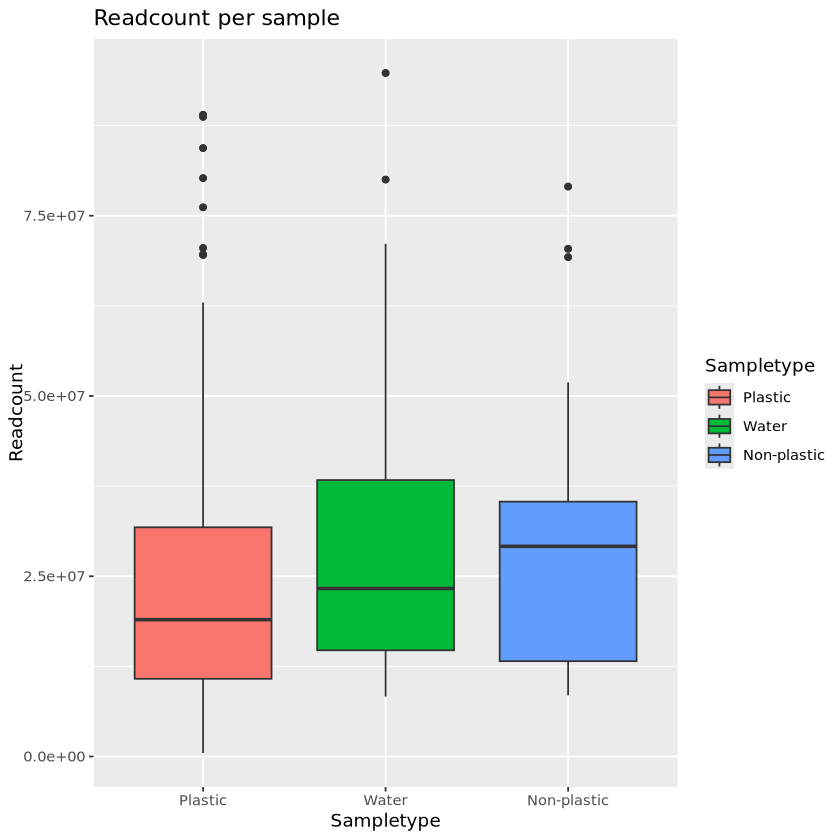

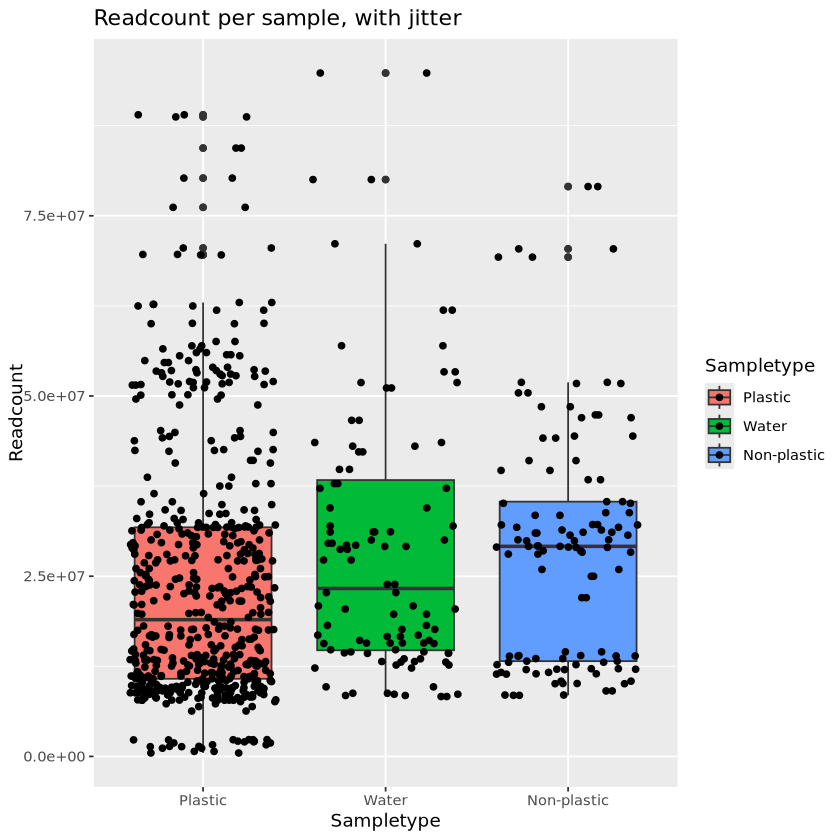

In [7]:
# Gives us a dataframe where row = sample and column = readcount. Also the sample metadata is added.
df_sample_readcount <- df_readcount %>%
    dplyr::select(!Description) %>%
    dplyr::select(contains("_1_val-Mut"))%>%
    pivot_longer(cols = everything(), names_to = "Sample", values_to = "Readcount") %>%
    mutate(Sample = str_remove(Sample, "_1_val-Mut")) %>%
    left_join(sample_metadata, by = join_by(Sample == run_accession)) %>%
    arrange(Sampletype, Substrate) %>%
    mutate(Sampletype = factor(Sampletype, levels = c("Plastic", "Water", "Non-plastic")))

plot_readcount <- df_sample_readcount %>%
    #filter(Readcount < 5000000) %>%
    ggplot(aes(Sampletype, Readcount, fill = Sampletype))+
        geom_boxplot()+
        scale_color_colorblind()
        #geom_violin()

plot_readcount + labs(title = "Readcount per sample")
plot_readcount + geom_jitter() + labs(title = "Readcount per sample, with jitter")

### Plots mutation percent, relative data


-----------
figure_df <- df_long_all_relative
-----------


Warning message:
“Removed 389218 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


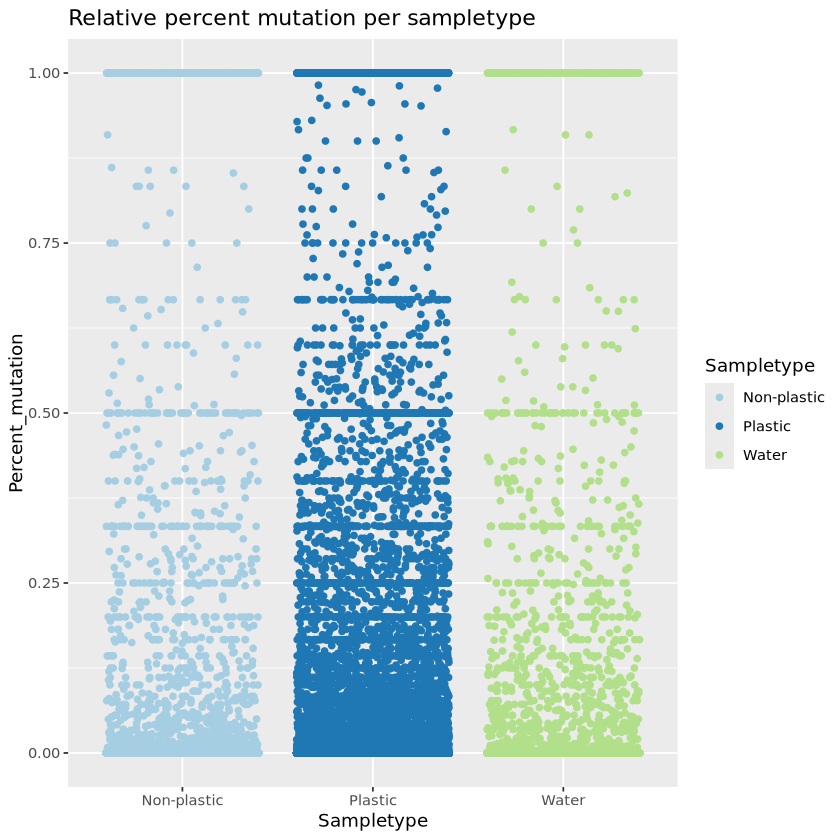

Warning message:
“Removed 389218 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


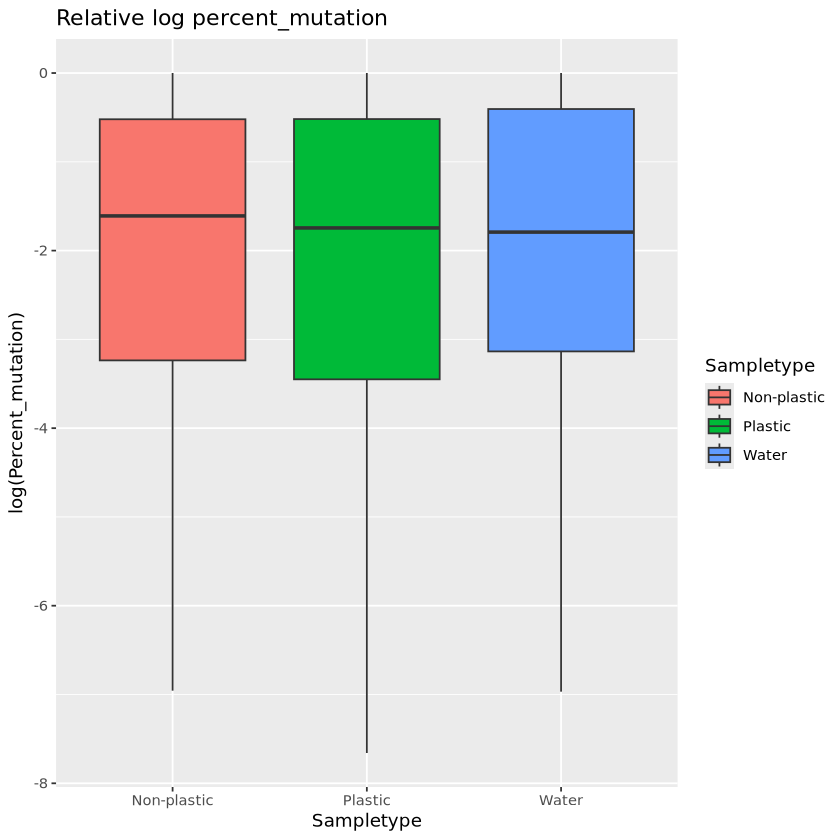

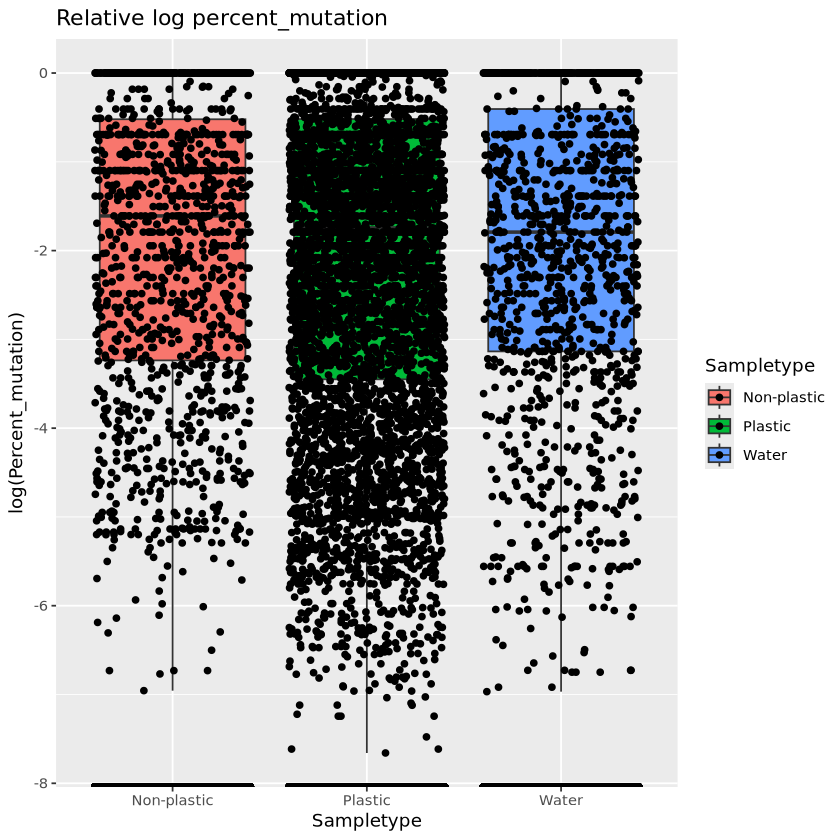

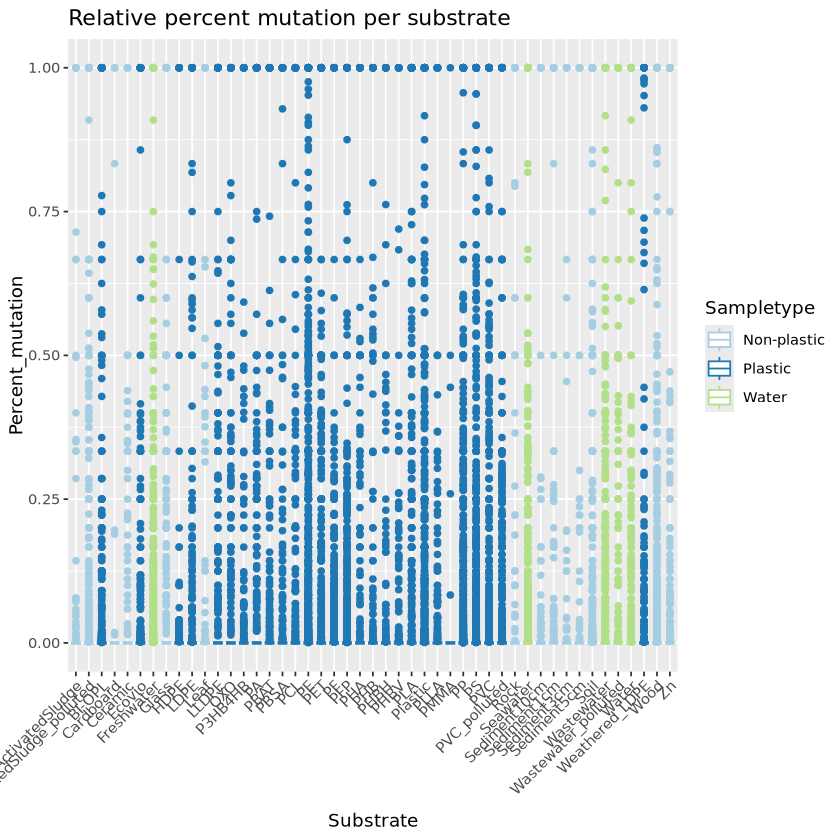

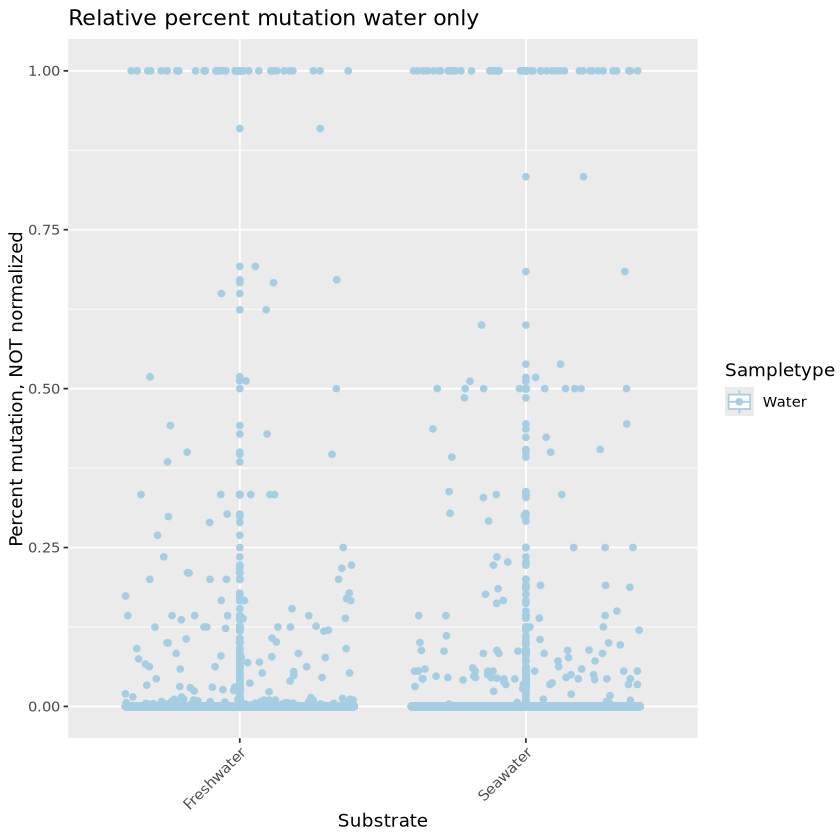

In [8]:
figure_df <- df_long_all_relative; cat("\n-----------\nfigure_df <- df_long_all_relative\n-----------\n")

# TILE
#figure_df %>%
#    ggplot(aes(Description, Sample, fill = Percent_mutation))+
#    geom_tile()

# JITTER
figure_df %>%
    ggplot(aes(Sampletype, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_jitter()+
        labs(title = "Relative percent mutation per sampletype")

# LOG BOXPLOT
plot_box_log <- figure_df %>%
    ggplot(aes(Sampletype, log(Percent_mutation), fill = Sampletype)) + 
        scale_color_brewer(palette = "Paired") + 
        geom_boxplot() +
        labs(title = "Relative log percent_mutation")

plot_box_log
plot_box_log + geom_jitter()

# BOXPLOT SUBSTRATE
plot_substrate <- figure_df %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Relative percent mutation per substrate")
plot_substrate + 
    geom_boxplot()

# WATER ONLY
figure_df %>%
    filter(Substrate == c("Seawater", "Freshwater")) %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_boxplot() +
        geom_jitter() +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Relative percent mutation water only") + 
        ylab("Percent mutation, NOT normalized")

### Plots mutation percent, normalized data


-----------
figure_df <- df_long_normalized
-----------


Warning message:
“Removed 21252 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 389394 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


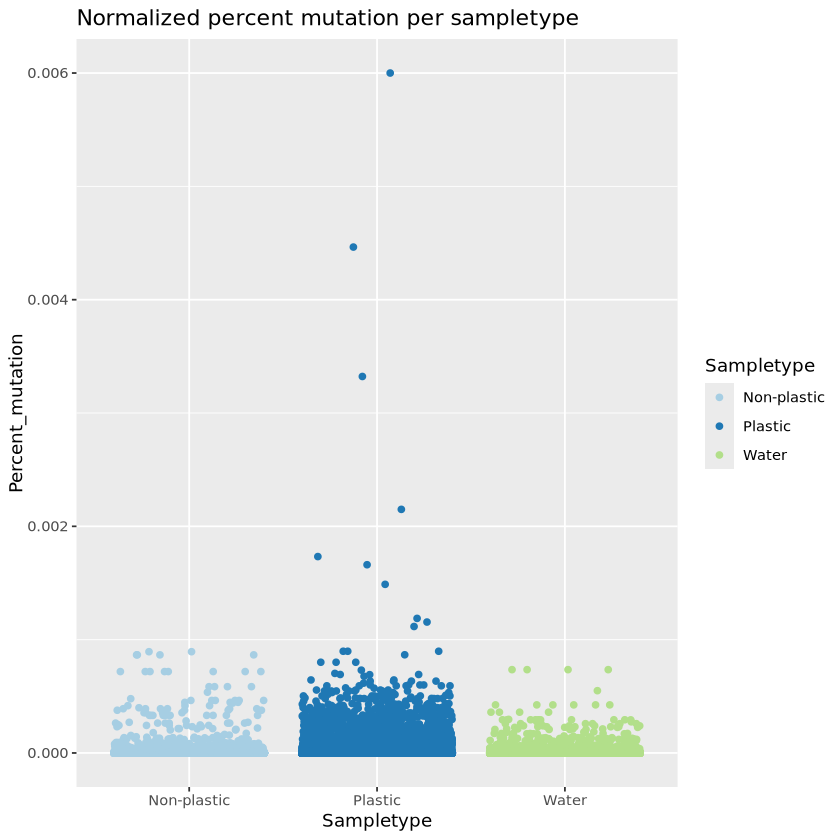

Warning message:
“Removed 389394 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 21252 rows containing missing values or values outside the scale range
(`geom_point()`).”


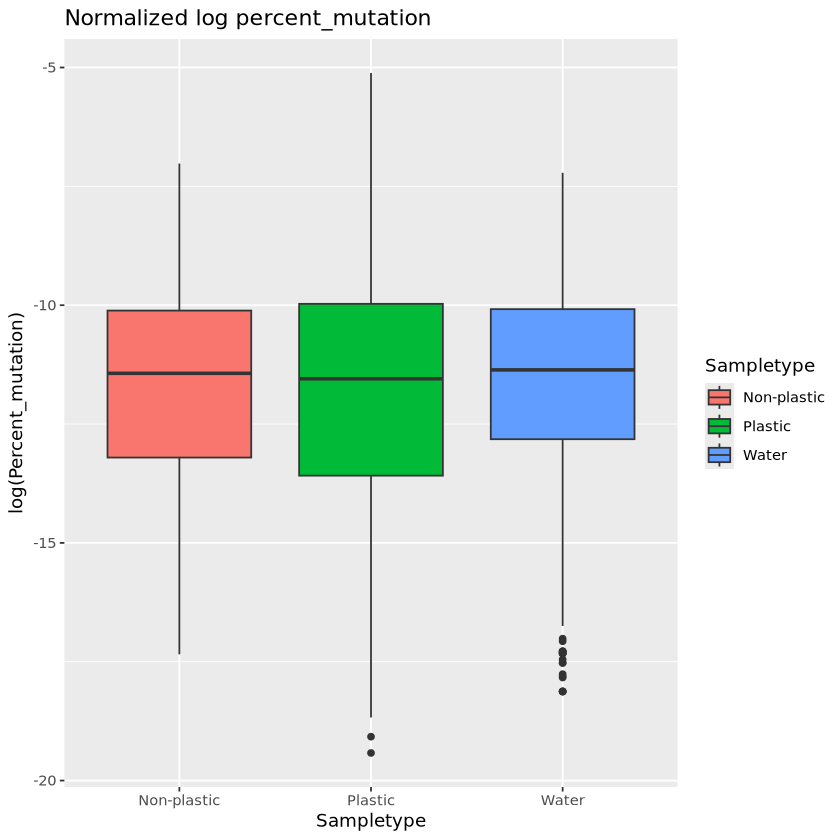

Warning message:
“Removed 21252 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 21252 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


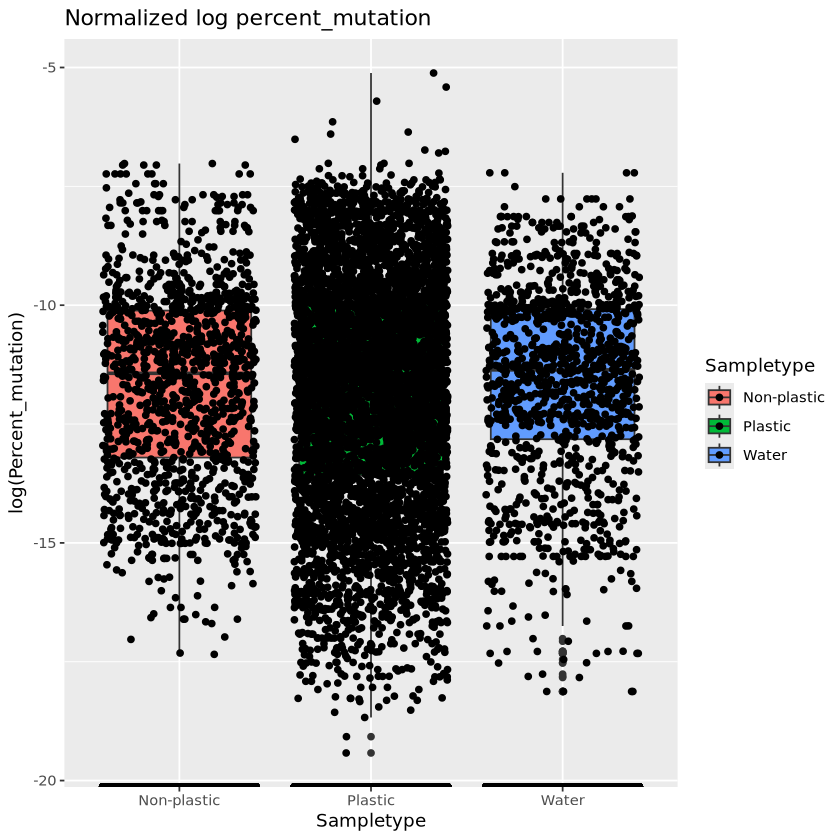

Warning message:
“Removed 1012 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 1012 rows containing missing values or values outside the scale range
(`geom_point()`).”


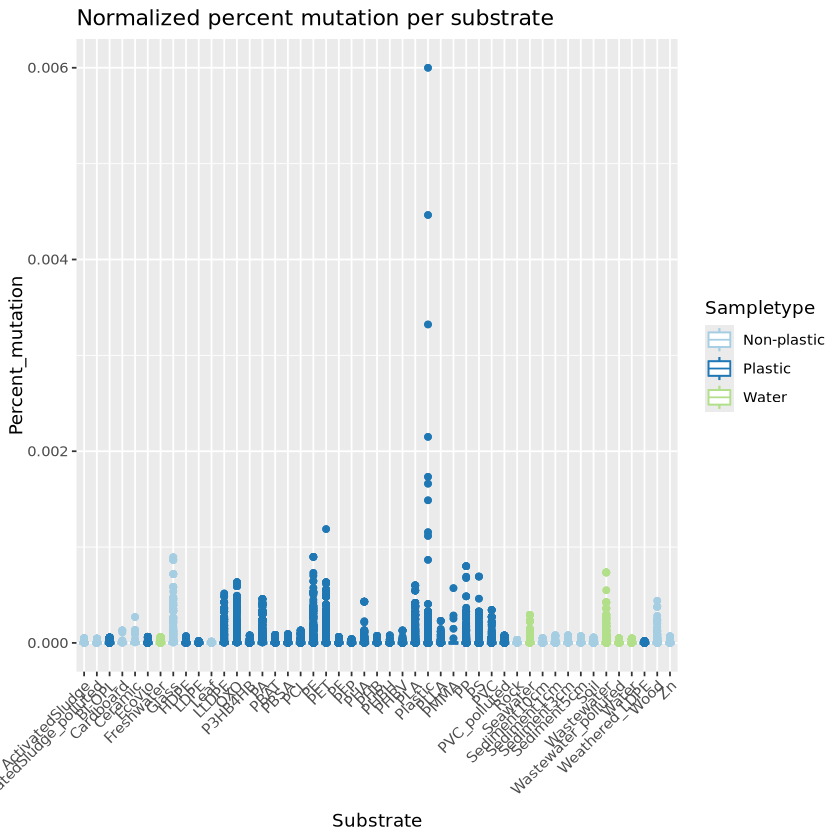

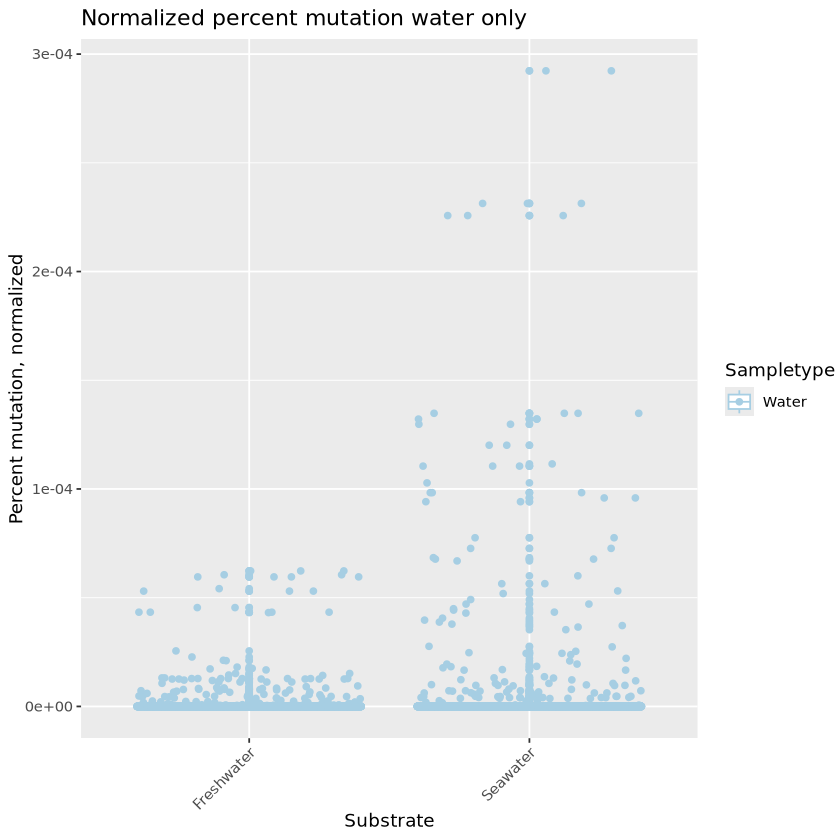

In [9]:
figure_df <- df_long_normalized; cat("\n-----------\nfigure_df <- df_long_normalized\n-----------\n")

# TILE
#figure_df %>%
#    ggplot(aes(Description, Sample, fill = Percent_mutation))+
#    geom_tile()

# JITTER
figure_df %>%
    ggplot(aes(Sampletype, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_jitter()+
        labs(title = "Normalized percent mutation per sampletype")

# LOG BOXPLOT
plot_box_log <- figure_df %>%
    ggplot(aes(Sampletype, log(Percent_mutation), fill = Sampletype)) + 
        scale_color_brewer(palette = "Paired") + 
        geom_boxplot() +
        labs(title = "Normalized log percent_mutation")

plot_box_log
plot_box_log + geom_jitter()

# SUBSTRATE
plot_substrate <- figure_df %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_boxplot() +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Normalized percent mutation per substrate")
plot_substrate + 
    geom_boxplot()

# WATER ONLY
figure_df %>%
    filter(Substrate == c("Seawater", "Freshwater")) %>%
    ggplot(aes(Substrate, Percent_mutation, col = Sampletype)) + 
        scale_color_brewer(palette = "Paired")+
        geom_boxplot() +
        geom_jitter() +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        labs(title = "Normalized percent mutation water only") + 
        ylab("Percent mutation, normalized")

# Microeco

## Using df_normalized

In [10]:
# Create dataframes for microeco to use
microeco_otutable <- df_normalized %>%
    column_to_rownames("Description") %>%
    # Replace all NA:s with zeros?
    mutate_all(~replace(., is.na(.), 0))


microeco_sampleinfo <- sample_metadata %>%
    dplyr::select(!contains(":")) %>%
    column_to_rownames("Sample")


microeco_taxtable <- df_normalized %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
        # Split further? Not needed if use per-mutation
            #df_counts$mutations %>%
            #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession") %>%
    column_to_rownames("Description") %>%
    dplyr::select("Resistance Mechanism", "Drug Class", "AMR Gene Family")
# Taxtable:
# AMR gene family: 47
# Drug Class: 28
# Resistance Mechanism: 6


# Create the microtable-class object 
mt <- microtable$new(otu_table = microeco_otutable, sample_table = microeco_sampleinfo, tax_table = microeco_taxtable)
mt$tidy_dataset()


137 taxa with 0 abundance are removed from the otu_table ...

44 samples with 0 abundance are removed from the otu_table ...



### LEFSE, AMR Gene Family, normalized

No taxa_abund list found. Calculate it with cal_abund function ...

The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

12 taxa found significant ...

After P value adjustment, 4 taxa found significant ...



Minimum LDA score: 3.44885137984351 maximum LDA score: 4.68455665351959

Taxa abundance table is stored in object$res_abund ...

lefse analysis result is stored in object$res_diff ...

The length of use_number is larger than taxa number in object$diff_data. Use all taxa ...



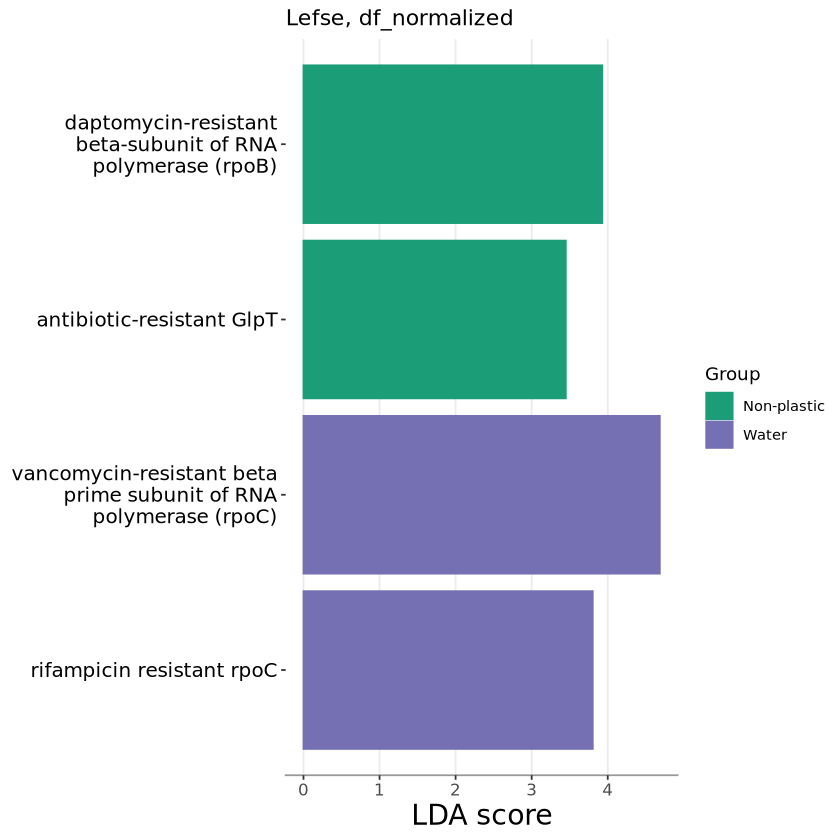

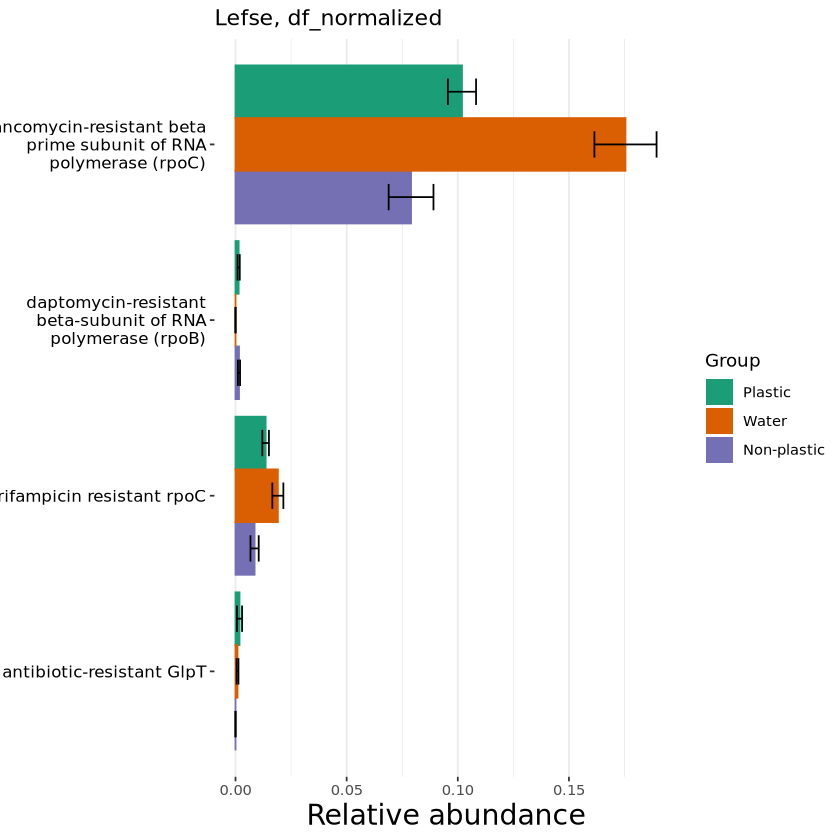

In [11]:
# Takes ~1 second
lefse_norm <- trans_diff$new(dataset = mt, method = "lefse", group = "Sampletype", alpha = 0.05, lefse_subgroup = NULL, taxa_level = "AMR Gene Family", boots = 999) 

# Not all genes are integers: (since they are all between 0 and 1)
#t1 <- trans_diff$new(dataset = mt, method = "ALDEx2_t", group = "Sampletype", alpha = 0.01) 

lefse_norm$plot_diff_bar(
    group_order = c("Plastic", "Non-plastic", "Water"),
    color_group_map = TRUE,
    threshold = 1
    ) + 
    scale_x_discrete(labels = label_wrap(30)) +
        labs(title = "Lefse, df_normalized")

lefse_norm$plot_diff_abund(
    use_number = 1:30
    ) + 
    scale_x_discrete(labels = label_wrap(30)) +
        labs(title = "Lefse, df_normalized")


### Random forest, AMR Gene Family, normalized

No taxa_abund list found. Calculate it with cal_abund function ...



The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

12 taxa found significant ...

After P value adjustment, 4 taxa found significant ...

Taxa abundance table is stored in object$res_abund ...

rf analysis result is stored in object$res_diff ...

The length of use_number is larger than taxa number in object$diff_data. Use all taxa ...

Warning message in geom_bar(stat = "identity", position = position_dodge(), ...):
“Ignoring unknown parameters: `add_sig`”


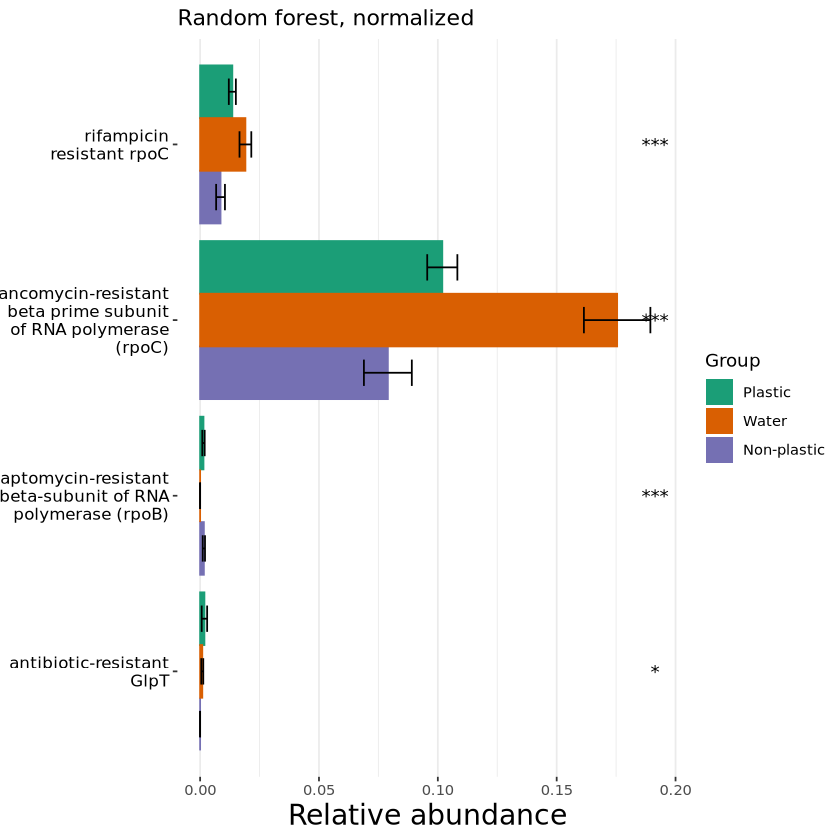

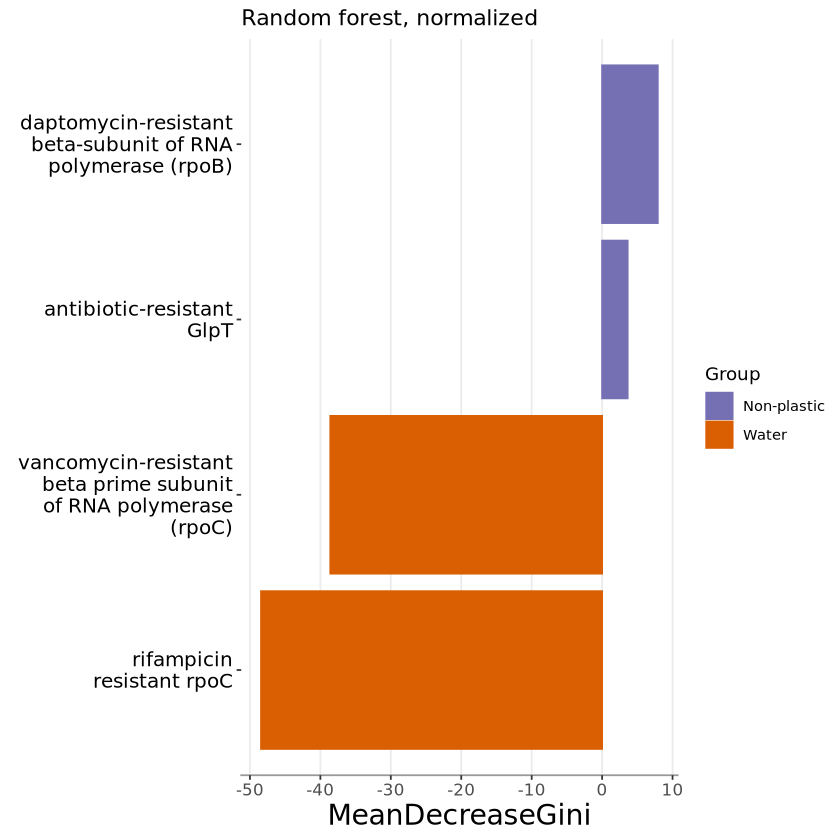

In [ ]:
# Takes ~3 minutes:
t_randomforest <- trans_diff$new(dataset = mt, method = "rf", group = "Sampletype", alpha = 0.05, taxa_level = "AMR Gene Family", boots = 999) 

t_randomforest$plot_diff_abund(
    color_group_map = TRUE, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, normalized")

t_randomforest$plot_diff_bar(
    color_group_map = TRUE, 
    use_number = 1:100, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, normalized")

## Using df_counts

In [12]:
# Using df_counts instead of the relative data from before
microeco_otutable_counts <- df_counts %>%
    column_to_rownames("Description") %>%
    # Replace all NA:s with zeros, since only done on relative data before
    mutate_all(~replace(., is.na(.), 0))


# Create a new sampleinfo where rownames match columnnames of otu_table
microeco_sampleinfo_counts <- data.frame(Sample_full = names(df_counts)) %>%
    # Get the samplename and type (Mut or WT) for each column
    mutate(
        Type = str_remove(Sample_full, ".*_val-"),
        run_accession = str_remove(Sample_full, "_[12]_val-(Mut|WT)"),
        Sample = str_remove(Sample_full, "_val-(Mut|WT)")
        )%>%
    # Remove extra row which came from 'names'
    filter(Sample_full != "Description") %>%
    # Add the metadata by run_accession
    left_join(x = ., y = sample_metadata, by = join_by(run_accession, Sample)) %>%    
    relocate(Sample_full, Type, Sample, Sampletype, Substrate) %>%
    dplyr::select(-study_accession, -c(Latitude, Longitude), run_accession) %>%
    column_to_rownames("Sample_full")


# Same taxtable as above


#head(microeco_sampleinfo_counts)
#head(microeco_otutable_counts)
#head(microeco_sampleinfo)


# Create the microtable-class object 
mt_counts <- microtable$new(otu_table = microeco_otutable_counts, sample_table = microeco_sampleinfo_counts, tax_table = microeco_taxtable)
mt_counts$tidy_dataset()


2 samples with 0 abundance are removed from the otu_table ...



### Creating paired ALDEx t-test and KW using count data

In [ ]:
# Takes ~15 seconds
aldex_t_counts <- trans_diff$new(dataset = mt_counts, method = "ALDEx2_t", by_ID = "Type", group = "Sampletype", taxa_level = "AMR Gene Family", paired.test = TRUE) # filter_thres = 0.0005)?

# Takes ~9 minutes
aldex_kw_counts <- trans_diff$new(dataset = mt_counts, method = "ALDEx2_kw", by_ID = "Type", group = "Sampletype", taxa_level = "AMR Gene Family", paired.test = TRUE) # filter_thres = 0.0005)?

No taxa_abund list found. Calculate it with cal_abund function ...



The result is stored in object$taxa_abund ...

Total 3 paired group for test ...

Run 1 : Plastic - Water ...


Input features number: 46

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 2 : Plastic - Non-plastic ...


Input features number: 45

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Run 3 : Water - Non-plastic ...


Input features number: 28

aldex.clr: generating Monte-Carlo instances and clr values

conditions vector supplied

operating in serial mode

computing center with all features

aldex.ttest: doing t-test

aldex.effect: calculating effect sizes

Taxa abundance table is stored in object$res_abund ...

ALDEx2_t analysis result is st

### Plotting paired ALDEx t-test using count data

Reorder taxa according to P.adj in res_diff from low to high ...



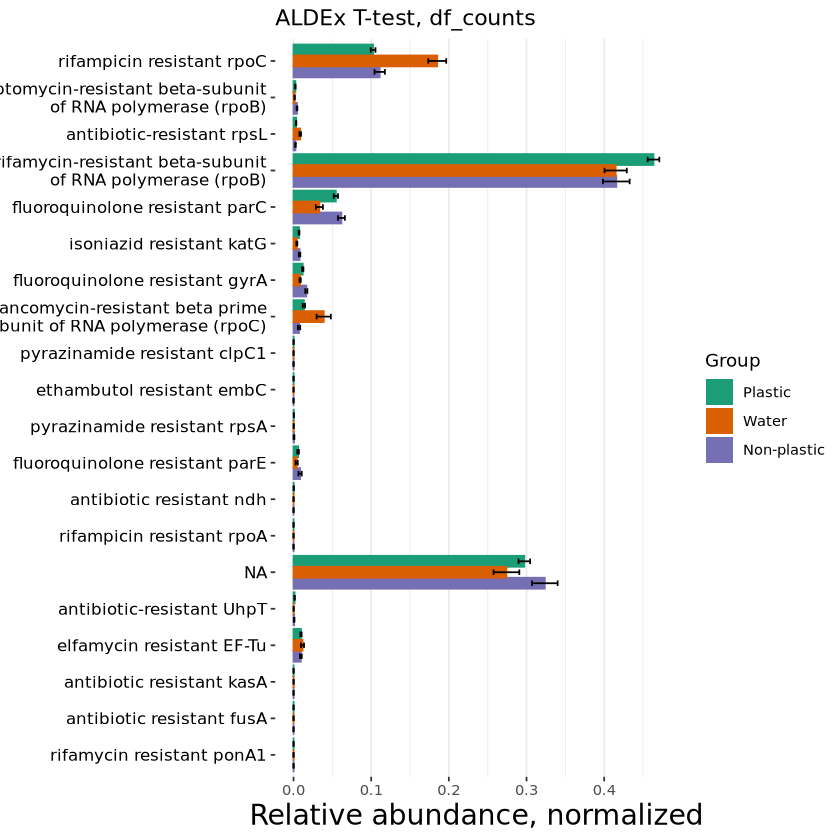

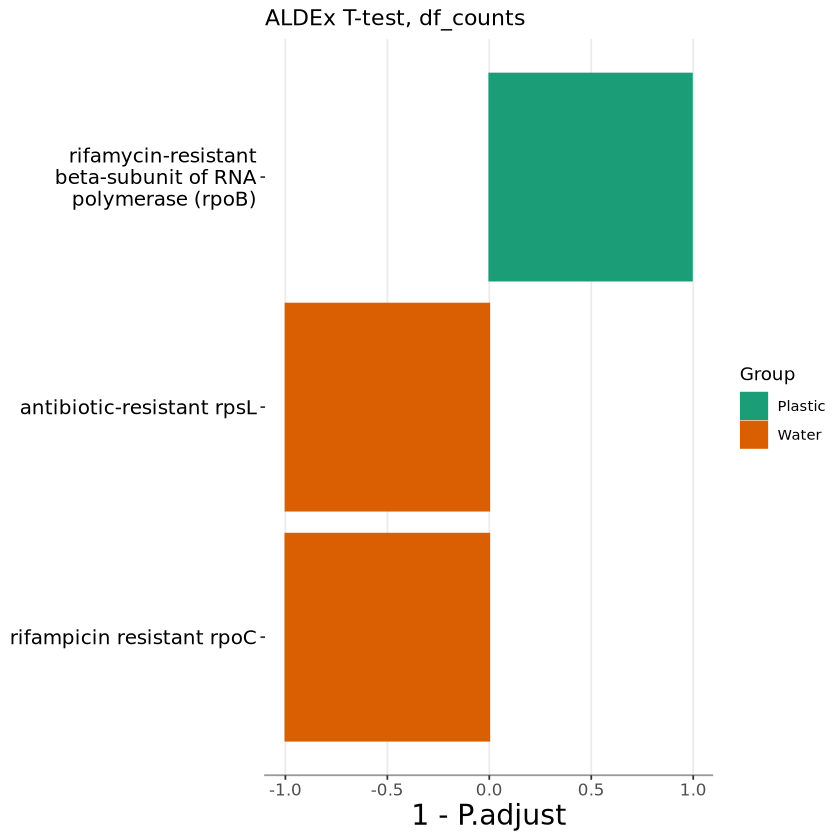

In [ ]:
#head(aldex_t_counts$res_diff)
#head(aldex_t_counts$res_abund)

aldex_t_counts$plot_diff_abund(
    use_number = 1:20, # IF 1000 is used, NA is visible
    select_taxa = NULL, 
    simplify_names = TRUE,
    keep_prefix = TRUE,
    group_order = NULL,
    order_x_mean = TRUE,
    coord_flip = TRUE,
    #add_sig = TRUE,
    ytitle_size = 17,
    color_group_map = TRUE
    ) + 
    scale_x_discrete(labels = label_wrap(35)) +
    labs(title = "ALDEx T-test, df_counts") +
    ylab("Relative abundance, normalized")
    

aldex_t_counts$plot_diff_bar(
    color_values = RColorBrewer::brewer.pal(8, "Dark2"),
    color_group_map = TRUE,
    use_number = 1:1000,
    threshold = NULL,
    select_group = "Plastic - Water",
#    select_group = "Plastic - Non-plastic",
#    select_group = "Water - Non-plastic",
    keep_prefix = TRUE,
    group_order = NULL,
    coord_flip = TRUE
    ) + 
    scale_x_discrete(labels = label_wrap(30)) +
    labs(title = "ALDEx T-test, df_counts")


### Plotting paired ALDEx KW using count data

Reorder taxa according to P.adj in res_diff from low to high ...



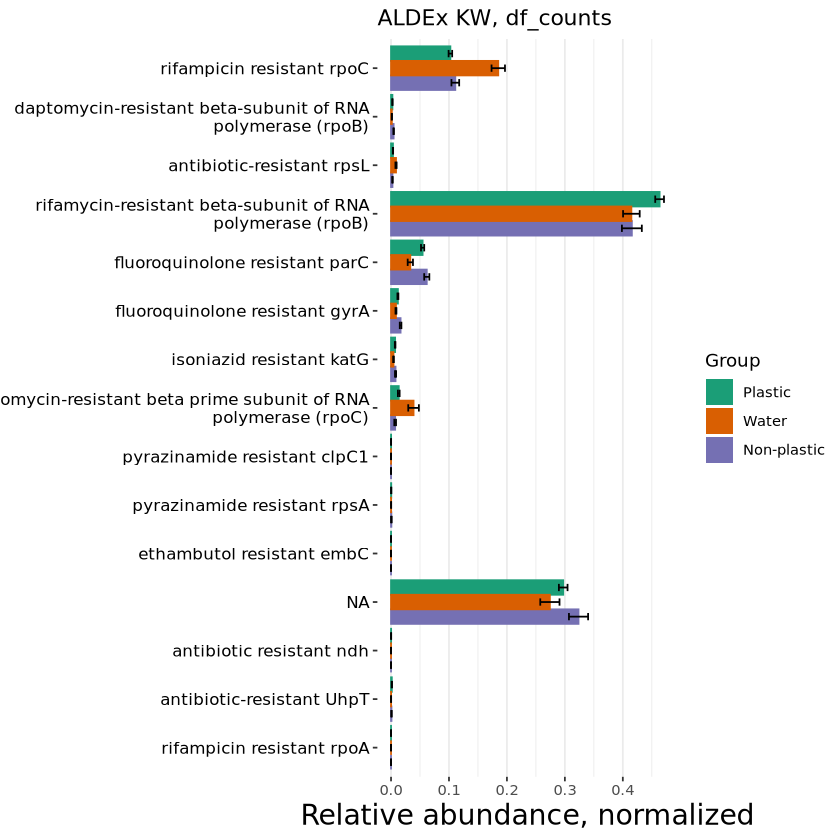

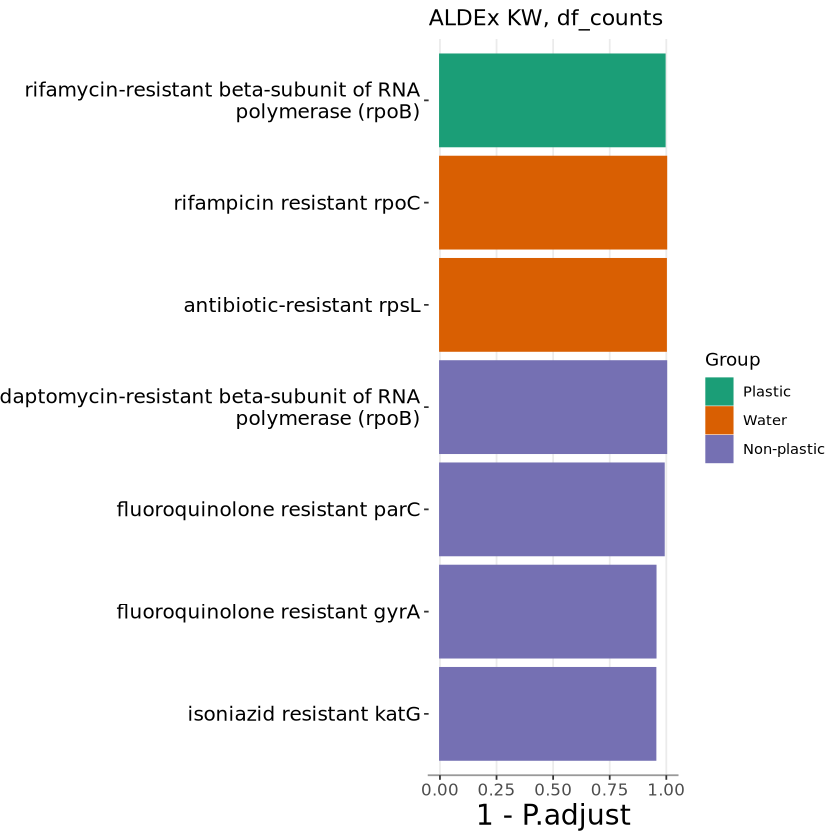

In [ ]:
aldex_kw_counts$plot_diff_abund(
    use_number = 1:15, 
    select_taxa = NULL, 
    simplify_names = TRUE,
    keep_prefix = TRUE,
    group_order = NULL,
    order_x_mean = TRUE,
    coord_flip = TRUE,
    #add_sig = TRUE,
    ytitle_size = 17,
    color_group_map = TRUE
    ) + 
        scale_x_discrete(labels = label_wrap(50)) +
        labs(title = "ALDEx KW, df_counts") + 
        ylab("Relative abundance, normalized")

aldex_kw_counts$plot_diff_bar(
    color_values = RColorBrewer::brewer.pal(8, "Dark2"),
    color_group_map = TRUE,
    use_number = 1:1000,
    threshold = NULL,
    select_group = "Plastic - Water",
#    select_group = "Plastic - Non-plastic",
#    select_group = "Water - Non-plastic",
    keep_prefix = TRUE,
    group_order = NULL,
    coord_flip = TRUE
    ) + 
        #theme(axis.text.y = element_text(angle = 60))
        scale_x_discrete(labels = label_wrap(50)) +
        labs(title = "ALDEx KW, df_counts")

### Lefse using count data

No taxa_abund list found. Calculate it with cal_abund function ...



The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

17 taxa found significant ...

After P value adjustment, 12 taxa found significant ...

Start lefse subgroup biomarkers check for Type ...

Remove 4 biomarkers after subgroup check ...

Warning message in lda.default(x, grouping, ...):
“variables are collinear”
Minimum LDA score: 1.43520264815205 maximum LDA score: 4.15201871369089

Taxa abundance table is stored in object$res_abund ...

lefse analysis result is stored in object$res_diff ...



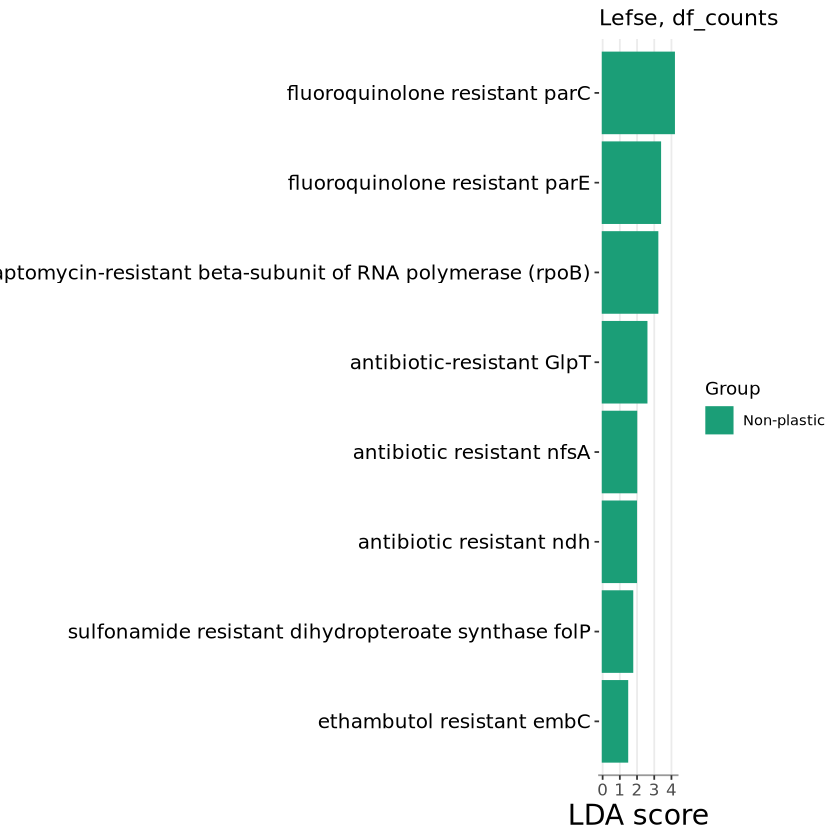

In [13]:
# Takes ~50 seconds
t1_lefse <- trans_diff$new(dataset = mt_counts, method = "lefse", group = "Sampletype", lefse_subgroup = "Type", alpha = 0.01, taxa_level = "AMR Gene Family", boots = 999)
t1_lefse$plot_diff_bar(use_number = 1:100) + #, width = 0.8, group_order = c("CW", "IW", "TW"))
    labs(title = "Lefse, df_counts")

### Random forest using count data

No taxa_abund list found. Calculate it with cal_abund function ...

rf analysis result is stored in object$res_diff ...

Warning message in geom_bar(stat = "identity", position = position_dodge(), ...):
“Ignoring unknown parameters: `add_sig`”


The result is stored in object$taxa_abund ...

Start Kruskal-Wallis rank sum test for Sampletype ...

26 taxa found significant ...

After P value adjustment, 22 taxa found significant ...



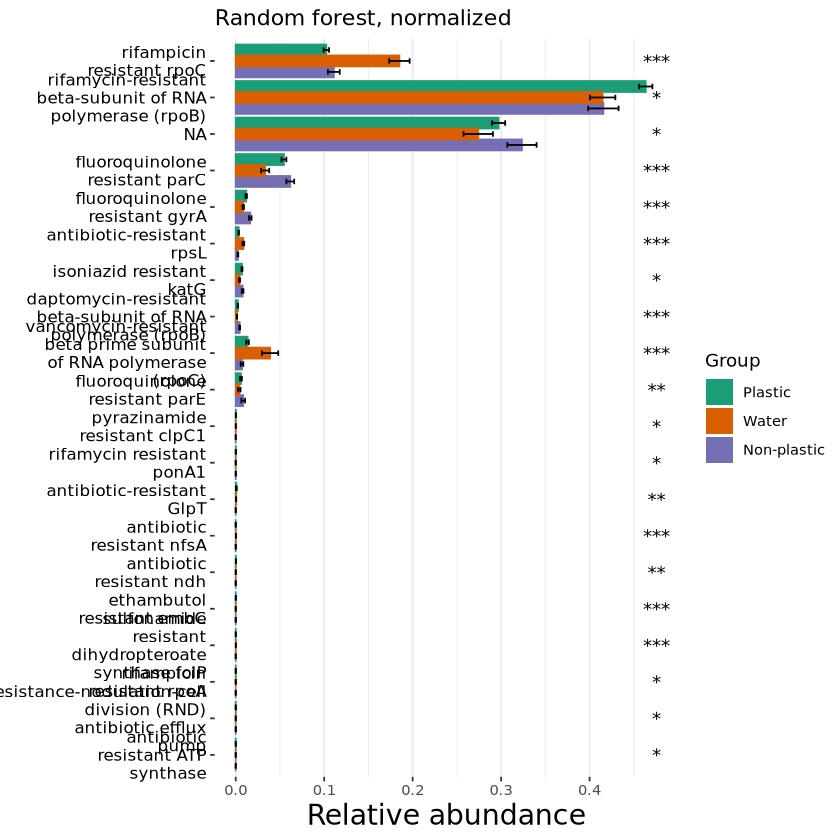

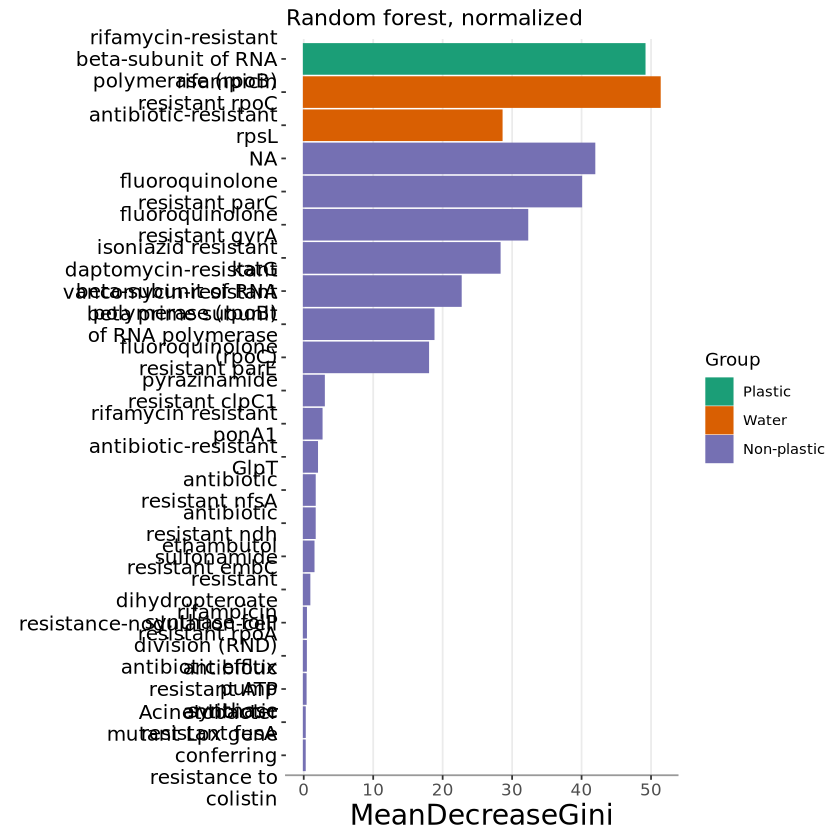

In [ ]:
# Takes ~15 minutes
t_randomforest_counts <- trans_diff$new(dataset = mt_counts, method = "rf", group = "Sampletype", alpha = 0.05, taxa_level = "AMR Gene Family", boots = 999) 

t_randomforest_counts$plot_diff_abund(
    color_group_map = TRUE, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, normalized")

t_randomforest_counts$plot_diff_bar(
    color_group_map = TRUE, 
    use_number = 1:100, 
    add_sig = TRUE
    ) +
    scale_x_discrete(labels = label_wrap(20))+
    labs(title = "Random forest, normalized")


# Wilcoxon rank sum tests

`summarise()` has grouped output by 'Sampletype'. You can override using the
`.groups` argument.



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_plastic$Mean and genes_mean_water$Mean
V = 42554, p-value = 8.53e-11
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -2.581998e-05  4.752480e-05
sample estimates:
(pseudo)median 
   4.75248e-05 



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_plastic$Mean and genes_mean_nonplastic$Mean
V = 41936, p-value = 4.793e-08
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon signed rank test with continuity correction

data:  genes_mean_nonplastic$Mean and genes_mean_water$Mean
V = 12491, p-value = 0.4009
alternative hypothesis: true location shift is not equal to 0


`summarise()` has grouped output by 'Sampletype'. You can override using the
`.groups` argument.


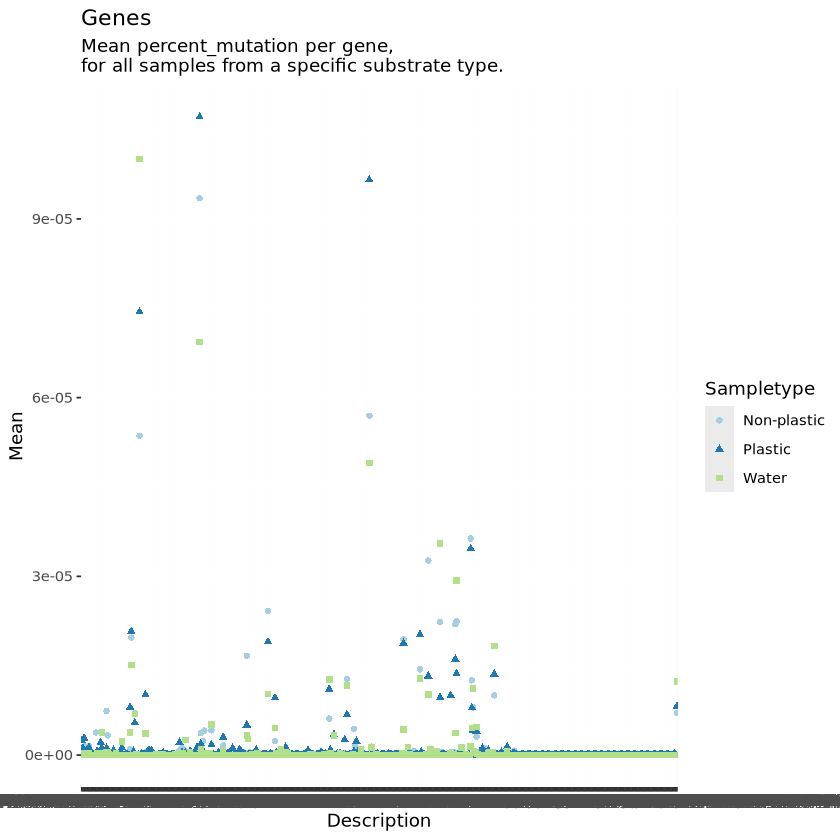


	Wilcoxon rank sum test with continuity correction

data:  samples_mean_plastic$Mean and samples_mean_water$Mean
W = 27021, p-value = 0.8488
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -6.244289e-06  1.602958e-05
sample estimates:
difference in location 
         -6.244289e-06 



	Wilcoxon rank sum test with continuity correction

data:  samples_mean_plastic$Mean and samples_mean_nonplastic$Mean
W = 30370, p-value = 0.5738
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  samples_mean_nonplastic$Mean and samples_mean_water$Mean
W = 5179, p-value = 0.4662
alternative hypothesis: true location shift is not equal to 0


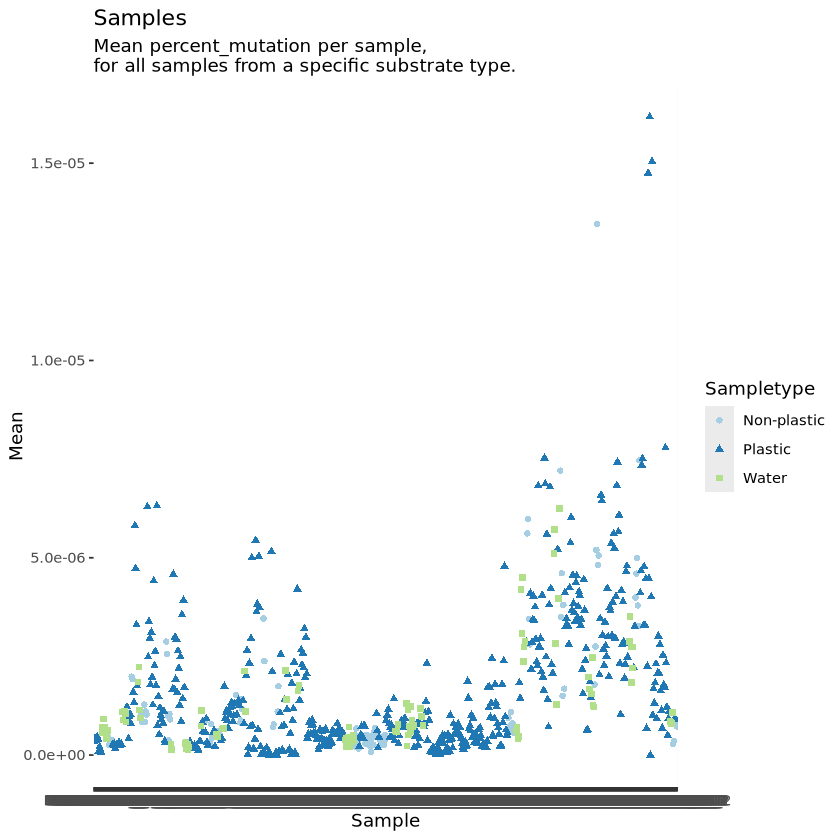

In [14]:
#head(df_long_normalized)

#GENES
# Calculating the mean value for each gene in a specific substrate type
df_mean_percent_genes <- df_long_normalized %>%
    filter(!is.na(Percent_mutation)) %>%
    #filter(Mutations != "Wildtype") %>%
    group_by(Sampletype, Description) %>%
    summarise(Mean = mean(Percent_mutation),)

#df_mean_percent_genes

plot_mean_genes <- df_mean_percent_genes %>% 
    ggplot(aes(Description, Mean, col = Sampletype, shape = Sampletype)) + 
        geom_point() +
        scale_color_brewer(palette = "Paired")+
        labs(title = "Genes",
        subtitle = "Mean percent_mutation per gene, \nfor all samples from a specific substrate type.")


plot_mean_genes
#print(df_mean_percent_genes, n = Inf)

genes_mean_plastic <- filter(df_mean_percent_genes, Sampletype == "Plastic")
genes_mean_water <- filter(df_mean_percent_genes, Sampletype == "Water")
genes_mean_nonplastic <- filter(df_mean_percent_genes, Sampletype == "Non-plastic")

# There are an equal number of samples in each group, and they occur in the same
# order, can compare between samples.
wilcox.test(x = genes_mean_plastic$Mean,
            y = genes_mean_water$Mean, 
            paired = TRUE,
            conf.int = TRUE)
wilcox.test(x = genes_mean_plastic$Mean,
            y = genes_mean_nonplastic$Mean, 
            paired = TRUE)
wilcox.test(x = genes_mean_nonplastic$Mean,
            y = genes_mean_water$Mean, 
            paired = TRUE)



# SAMPLES
# Calculating the mean value for each sample in a specific substrate type
df_mean_percent_samples <- df_long_normalized %>%
    filter(!is.na(Percent_mutation)) %>%
    filter(Mutations != "Wildtype") %>%
    group_by(Sampletype, Sample) %>%
    summarise(Mean = mean(Percent_mutation),)

#df_mean_percent_samples

plot_mean_samples <- df_mean_percent_samples %>% 
    ggplot(aes(Sample, Mean, col = Sampletype, shape = Sampletype)) + 
        geom_point() +
        scale_color_brewer(palette = "Paired") + 
    labs(title = "Samples",
         subtitle = "Mean percent_mutation per sample, \nfor all samples from a specific substrate type.")

plot_mean_samples
#print(df_mean_percent_samples, n = Inf)

samples_mean_plastic <- filter(df_mean_percent_samples, Sampletype == "Plastic")
samples_mean_water <- filter(df_mean_percent_samples, Sampletype == "Water")
samples_mean_nonplastic <- filter(df_mean_percent_samples, Sampletype == "Non-plastic")

# There are not an equal number of samples per group:
#dim(samples_mean_plastic)
#dim(samples_mean_water)
#dim(samples_mean_nonplastic)
wilcox.test(x = samples_mean_plastic$Mean,
            y = samples_mean_water$Mean, 
            conf.int = TRUE)
wilcox.test(x = samples_mean_plastic$Mean,
            y = samples_mean_nonplastic$Mean)
wilcox.test(x = samples_mean_nonplastic$Mean,
            y = samples_mean_water$Mean)


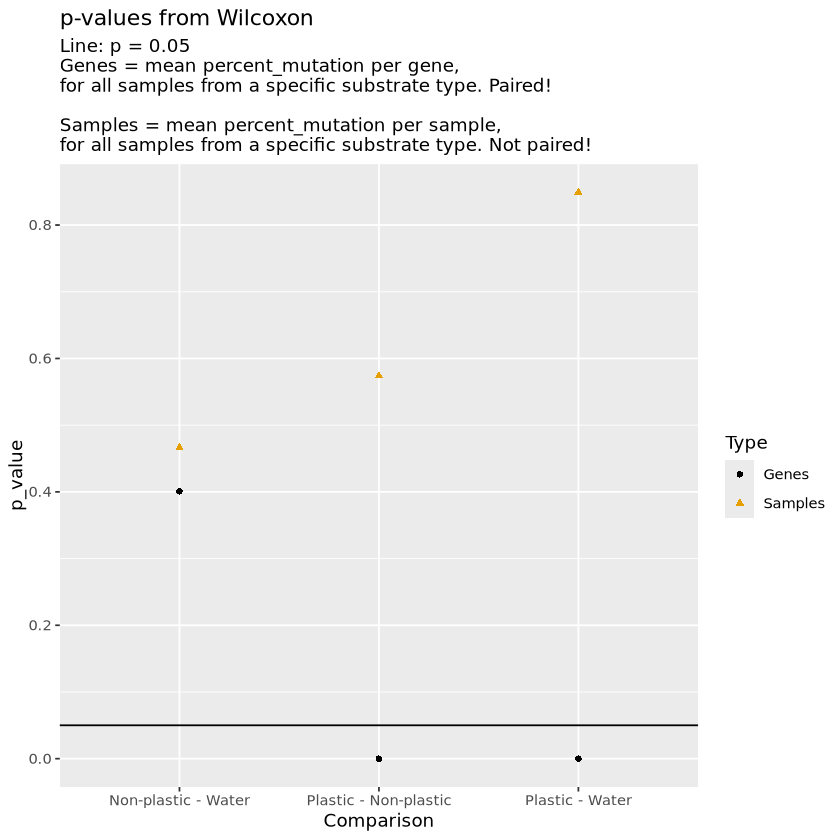

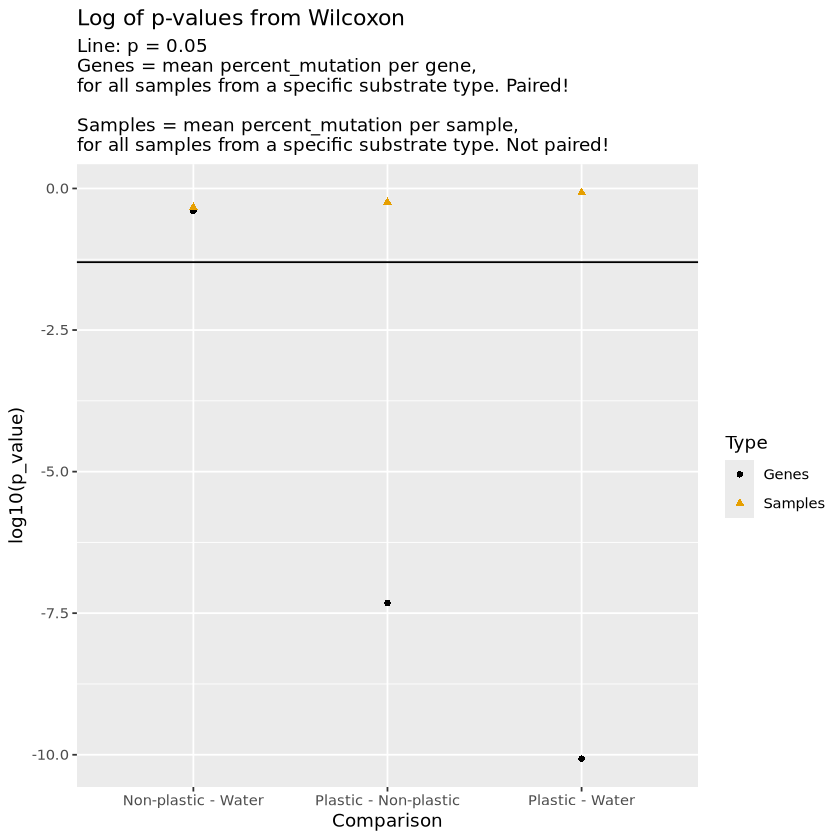

In [ ]:
# Genes:
# 8.53e-11 # Plastic - Water
# 4.793e-08 # Plastic - Non-plastic
# 0.4009 # Nonplastic - Water

# Samples:
# 0.8488 # Plastic - Water
# 0.5738 # Plastic - Non-plastic
# 0.4662 # Nonplastic - Water

p_values <- data.frame(Comparison = c("Plastic - Water", "Plastic - Non-plastic", "Non-plastic - Water"),
           Genes = c(8.53e-11, 4.793e-08, 0.4009), 
           Samples = c(0.8488, 0.5738, 0.4662)) %>% 
    pivot_longer(!Comparison, names_to = "Type", values_to = "p_value")

# NORMAL
p_values %>%
    ggplot(aes(Comparison, p_value, col = Type, shape = Type))+
       #scale_color_brewer(palette = "Paired") + 
       scale_color_colorblind() +
       geom_point()+
       geom_hline(yintercept = 0.05) + 
       labs(title = "p-values from Wilcoxon",
            subtitle = "Line: p = 0.05\nGenes = mean percent_mutation per gene, \nfor all samples from a specific substrate type. Paired!\n\nSamples = mean percent_mutation per sample, \nfor all samples from a specific substrate type. Not paired!")

# LOG
p_values %>%
    ggplot(aes(Comparison, log10(p_value), col = Type, shape = Type))+
       #scale_color_brewer(palette = "Paired") + 
       scale_color_colorblind() +
       geom_point()+
       geom_hline(yintercept = log10(0.05)) + 
       labs(title = "Log of p-values from Wilcoxon",
       subtitle = "Line: p = 0.05\nGenes = mean percent_mutation per gene, \nfor all samples from a specific substrate type. Paired!\n\nSamples = mean percent_mutation per sample, \nfor all samples from a specific substrate type. Not paired!")

# TaxonomyTest

In [ ]:
metaxa_dc <- read_tsv("storeDir/MetaxaQR_dc/collected_data_unique_run_id.txt", show_col_types = FALSE) %>%
    rename_at(vars(ends_with('_unique_run_id')), ~ str_remove(., "\\_unique_run_id")) %>%
    # Split the taxa into columns for KronaTools to use and place them last.
    separate_wider_delim(Taxa, delim = ";", names = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus")) %>%
    relocate(c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus"), .after = everything())

In [43]:
metaxa_dc %>%
    dplyr::select(DRR528402, Kingdom:Genus) %>%
    head()
    #write_tsv(file = "metaxa_dc_DRR528402.tsv")

DRR528402,Kingdom,Phylum,Class,Order,Family,Genus
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Candidatus Aenigmarchaeum,Unclassified Candidatus Aenigmarchaeum
0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Unclassified Aenigmarchaeales,
0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,uncultured archaeon,Unclassified uncultured archaeon
0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Unclassified Aenigmarchaeia,,
0,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,Unclassified Deep Sea Euryarchaeotic GroupDSEG,,
0,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,uncultured archaeon,Unclassified uncultured archaeon,


In [ ]:
#samples_plastic <- sample_metadata %>%
#    filter(Sampletype == "Plastic")

metaxa_dc %>%
    dplyr::select(DRR528401, DRR528402, Kingdom:Genus) %>%
    rowwise() %>%
    mutate(sum = sum(!(Kingdom:Genus))))

DRR528401,DRR528402,Kingdom,Phylum,Class,Order,Family,Genus,sum
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
0,0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Candidatus Aenigmarchaeum,Unclassified Candidatus Aenigmarchaeum,0
0,0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,Unclassified Aenigmarchaeales,,0
0,0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Aenigmarchaeales,uncultured archaeon,Unclassified uncultured archaeon,0
0,0,Archaea,Aenigmarchaeota,Aenigmarchaeia,Unclassified Aenigmarchaeia,,,0
0,0,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,Unclassified Deep Sea Euryarchaeotic GroupDSEG,,,0
0,0,Archaea,Aenigmarchaeota,Deep Sea Euryarchaeotic GroupDSEG,uncultured archaeon,Unclassified uncultured archaeon,,0
0,0,Archaea,Aenigmarchaeota,Deep Sea,Unclassified Deep Sea,,,0
0,0,Archaea,Aenigmarchaeota,Unclassified Aenigmarchaeota,,,,0
0,0,Archaea,Altiarchaeota,Altiarchaeia,Altiarchaeales,Altiarchaeaceae,Candidatus Altiarchaeum,0


: 

In [ ]:
#df_counts[which(str_detect(df_counts$Description, 'A1085V')), ]
#df_counts

#head(microeco_otutable)
#microeco_otutable
#head(microeco_sampleinfo)
#head(microeco_taxtable)
#microeco_taxtable
#sum(names(microeco_otutable) %in% rownames(microeco_sampleinfo))
#dim(microeco_sampleinfo)

#head(df_relative)
#head(df_normalized)
#head(df_counts)
#head(df_sample_metadata)

#data(selex)
#selex